# 🥚 Análise de Série Temporal — Preço de Ovos (1900–1993)

Este notebook analisa a série `eggs.csv`, que contém o **preço médio anual de ovos** nos EUA de 1900 a 1993.

Por ser uma série **anual** (frequência = 1), não há componente sazonal — o modelo resultante será um **ARIMA** simples, sem a parte sazonal.

### Fluxo de análise
1. Carregamento e visualização
2. Decomposição da tendência
3. Teste de estacionariedade
4. Transformações (se necessário)
5. Identificação via ACF / PACF
6. Ajuste do modelo ARIMA
7. Diagnóstico dos resíduos
8. Previsão

---
## 0. Pacotes

In [2]:
library(forecast)
library(tseries)
library(ggplot2)

cat("Pacotes carregados!\n")

Pacotes carregados!


---
## 1. Carregamento e visualização

O CSV tem três colunas: `ds` (data), `y` (valor) e `unique_id` (identificador da série).
Extraímos apenas `ds` e `y`, e convertemos para objeto `ts` com `frequency = 1` (anual).

In [3]:
# Leitura e conversão para ts
dados <- read.csv("eggs.csv")
dados <- dados[order(dados$ds), ]

ano_inicio <- as.integer(format(as.Date(dados$ds[1]), "%Y"))

ts_data <- ts(dados$y, start = ano_inicio, frequency = 1)

cat("Classe    :", class(ts_data), "\n")
cat("Início    :", start(ts_data), "\n")
cat("Fim       :", end(ts_data), "\n")
cat("Frequência:", frequency(ts_data), "(anual)\n")
cat("N obs     :", length(ts_data), "\n")
print(summary(ts_data))

Classe    : ts 
Início    : 1900 1 
Fim       : 1993 1 
Frequência: 1 (anual)
N obs     : 94 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  62.27  148.87  209.15  206.15  276.71  358.78 


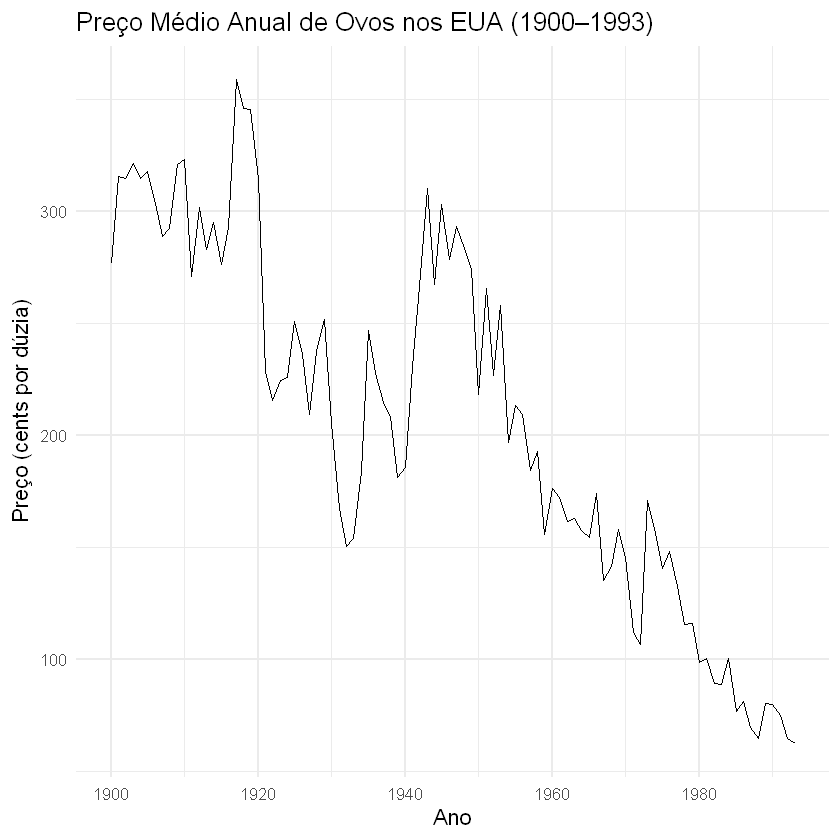

In [4]:
autoplot(ts_data) +
  labs(
    title = "Preço Médio Anual de Ovos nos EUA (1900–1993)",
    x     = "Ano",
    y     = "Preço (cents por dúzia)"
  ) +
  theme_minimal(base_size = 13)

**Observações:**

- Há uma **tendência de queda** clara ao longo do século, especialmente após os anos 1920.
- A variância parece relativamente estável (sem explosão proporcional ao nível), então a transformação logarítmica pode **não ser obrigatória** — mas vamos verificar.
- Não há sazonalidade (série anual).
- Há um pico notável por volta de 1917–1919, possivelmente relacionado à 1ª Guerra Mundial.

---
## 2. Decomposição da Tendência

Como a série é anual (`frequency = 1`), não existe componente sazonal para decompor.
Usamos uma **média móvel** para isolar a tendência e visualizar o resíduo.


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Warning message:
"Removed 4 rows containing missing values or values outside the scale range
(`geom_line()`)."


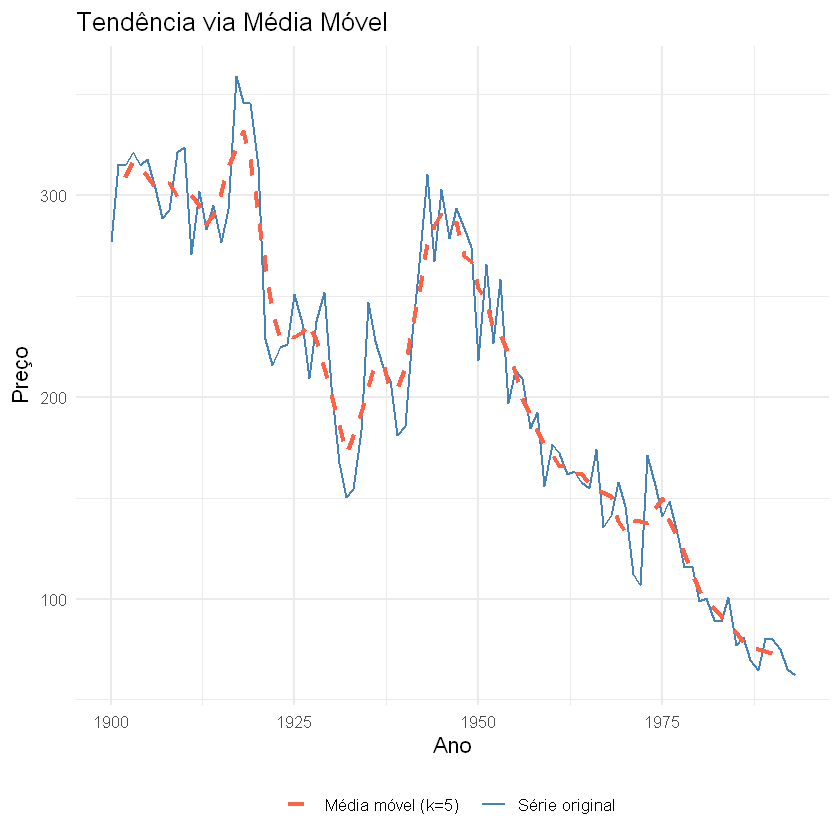

In [5]:
# Média móvel de ordem 5 para suavizar a tendência
library(zoo)
tendencia <- rollmean(ts_data, k = 5, fill = NA)

df_plot <- data.frame(
  ano       = as.numeric(time(ts_data)),
  original  = as.numeric(ts_data),
  tendencia = as.numeric(tendencia)
)

ggplot(df_plot, aes(x = ano)) +
  geom_line(aes(y = original,  color = "Série original"), linewidth = 0.8) +
  geom_line(aes(y = tendencia, color = "Média móvel (k=5)"), linewidth = 1.2, linetype = "dashed") +
  scale_color_manual(values = c("Série original" = "steelblue", "Média móvel (k=5)" = "tomato")) +
  labs(title = "Tendência via Média Móvel", x = "Ano", y = "Preço", color = NULL) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "bottom")

---
## 3. Teste de Estacionariedade

Modelos ARIMA exigem série **estacionária** (média e variância constantes no tempo).

Para confirmar nossa suspeita de tendencia, Vamos realizar os testes de Dickey-Fuller Aumentado e de KPSS que verifica se a série é estacionária.

- **ADF**: $H_0$ = tem raiz unitária (não estacionária). $p < 0{,}05$ → estacionária.
- **KPSS**: $H_0$ = é estacionária. $p < 0{,}05$ → **não** estacionária.

In [10]:
cat("=== Teste ADF — Série Original ===\n")
print(adf.test(ts_data))

cat("\n=== Teste KPSS — Série Original ===\n")
print(kpss.test(ts_data))

=== Teste ADF — Série Original ===



	Augmented Dickey-Fuller Test

data:  ts_data
Dickey-Fuller = -2.3934, Lag order = 4, p-value = 0.414
alternative hypothesis: stationary


=== Teste KPSS — Série Original ===


Warning message in kpss.test(ts_data):
"p-value smaller than printed p-value"



	KPSS Test for Level Stationarity

data:  ts_data
KPSS Level = 1.9812, Truncation lag parameter = 3, p-value = 0.01



---
## 4. Transformações para Estacionarizar

Como a série provavelmente **não é estacionária** (tendência decrescente evidente), aplicamos:

1. **Transformação Box-Cox** (ou log) — para estabilizar variância se necessário
2. **Diferenciação simples** — para remover tendência

Usamos `ndiffs()` para determinar automaticamente o número de diferenças necessárias.

In [9]:
# Verificando lambda ótimo da transformação Box-Cox
lambda <- BoxCox.lambda(ts_data)
cat("Lambda Box-Cox ótimo:", round(lambda, 3), "\n")
cat("(lambda ≈ 1 → transformação pouco necessária; lambda ≈ 0 → log)\n\n")

# Número de diferenças sugeridas
cat("Diferenças simples sugeridas (ndiffs)  :", ndiffs(ts_data), "\n")
cat("Diferenças sazonais sugeridas (nsdiffs):", nsdiffs(ts_data), "(esperado 0, série anual)\n")

Lambda Box-Cox ótimo: 0.396 
(lambda ≈ 1 → transformação pouco necessária; lambda ≈ 0 → log)

Diferenças simples sugeridas (ndiffs)  : 1 


ERROR: Error in nsdiffs(ts_data): Non seasonal data


Diferenças aplicadas: 1 


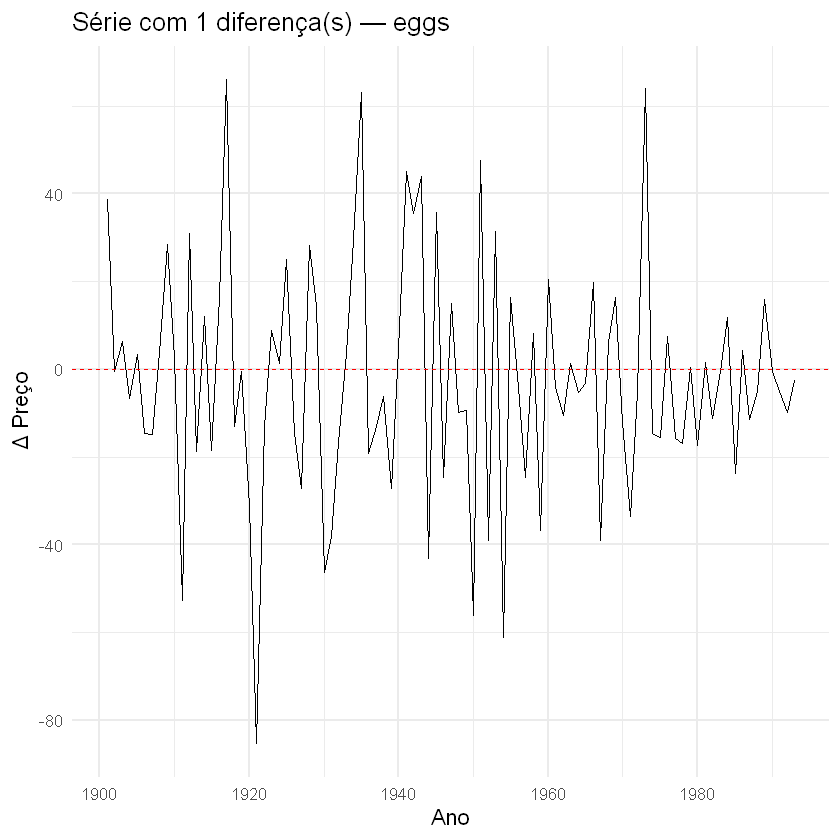

In [11]:
# Aplicando diferenciação simples
d <- ndiffs(ts_data)   # número de diferenças indicado

ts_diff <- ts_data
for (i in seq_len(d)) ts_diff <- diff(ts_diff)

cat("Diferenças aplicadas:", d, "\n")

autoplot(ts_diff) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  labs(
    title = paste0("Série com ", d, " diferença(s) — eggs"),
    x = "Ano", y = "Δ Preço"
  ) +
  theme_minimal(base_size = 13)

In [12]:
# Re-testando após diferenciação
cat("=== Teste ADF — Série Diferenciada ===\n")
print(adf.test(ts_diff))

cat("\n=== Teste KPSS — Série Diferenciada ===\n")
print(kpss.test(ts_diff))

=== Teste ADF — Série Diferenciada ===


Warning message in adf.test(ts_diff):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  ts_diff
Dickey-Fuller = -5.8255, Lag order = 4, p-value = 0.01
alternative hypothesis: stationary


=== Teste KPSS — Série Diferenciada ===


Warning message in kpss.test(ts_diff):
"p-value greater than printed p-value"



	KPSS Test for Level Stationarity

data:  ts_diff
KPSS Level = 0.060998, Truncation lag parameter = 3, p-value = 0.1



Aplicando a diferença na série, nós verificamos que a série ficou estacionária.

---
## 5. Identificação do Modelo — ACF e PACF

Com a série estacionária, analisamos os correlogramas para identificar as ordens $p$ e $q$:

| Padrão observado | Interpretação |
|-----------------|---------------|
| ACF corta no lag $q$, PACF decai | Processo **MA(q)** |
| PACF corta no lag $p$, ACF decai | Processo **AR(p)** |
| Ambos decaem gradualmente | Processo **ARMA(p,q)** |

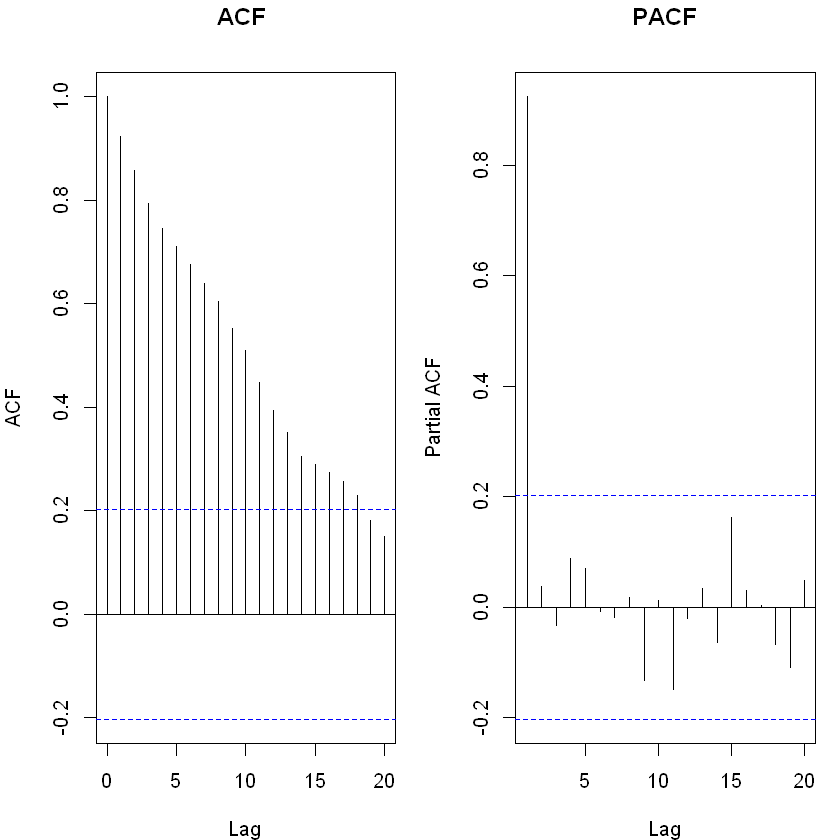

In [14]:
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
acf(ts_data,  lag.max = 20, main = "ACF ")
pacf(ts_data, lag.max = 20, main = "PACF")

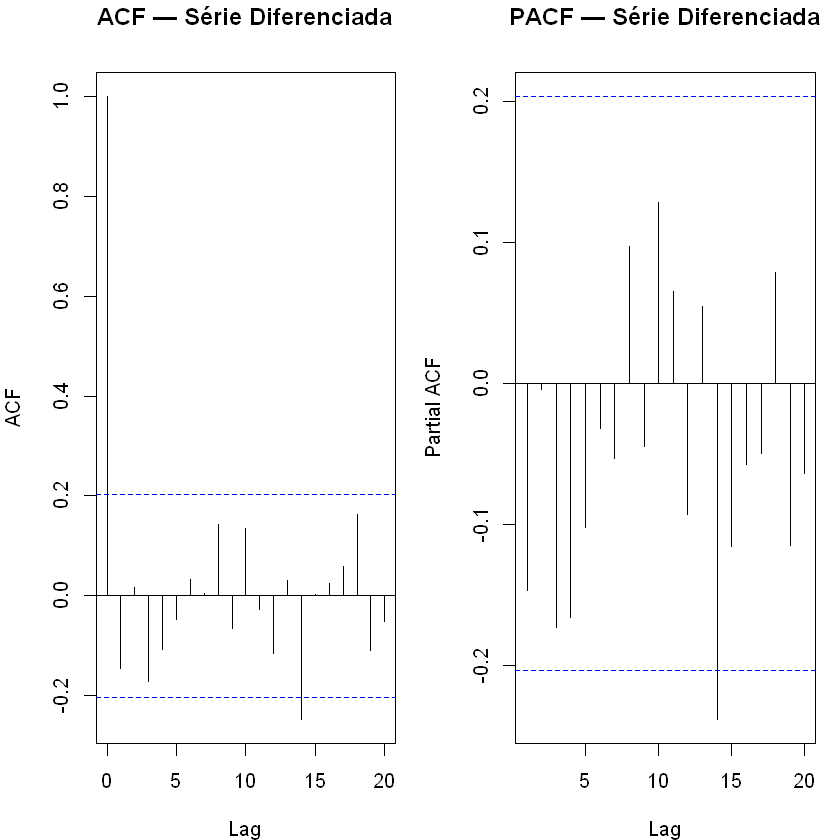

In [13]:
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
acf(ts_diff,  lag.max = 20, main = "ACF — Série Diferenciada")
pacf(ts_diff, lag.max = 20, main = "PACF — Série Diferenciada")

**Leitura:** Com base nos correlogramas, identificamos candidatos para as ordens $p$ e $q$. O `auto.arima()` na próxima seção vai confirmar a escolha ótima via AIC/BIC.

---
## 6. Ajuste do Modelo ARIMA

Como não há sazonalidade, o modelo é da forma $\text{ARIMA}(p, d, q)$.

Ajustamos dois modelos para comparar:
- **`auto.arima()`** — seleção automática por AIC
- **Modelo manual** — baseado na leitura do ACF/PACF

In [15]:
# Seleção automática
modelo_auto <- auto.arima(
  ts_data,
  stepwise      = FALSE,
  approximation = FALSE,
  trace         = TRUE
)

cat("\n=== Modelo selecionado automaticamente ===\n")
summary(modelo_auto)


 ARIMA(0,1,0)                    : 878.7962
 ARIMA(0,1,0) with drift         : 880.2029
 ARIMA(0,1,1)                    : 879.0695
 ARIMA(0,1,1) with drift         : 880.1778
 ARIMA(0,1,2)                    : 881.0858
 ARIMA(0,1,2) with drift         : 881.9568
 ARIMA(0,1,3)                    : 879.8536
 ARIMA(0,1,3) with drift         : 879.6908
 ARIMA(0,1,4)                    : 881.6176
 ARIMA(0,1,4) with drift         : 881.1212
 ARIMA(0,1,5)                    : 883.9025
 ARIMA(0,1,5) with drift         : 883.34
 ARIMA(1,1,0)                    : 879.1049
 ARIMA(1,1,0) with drift         : 880.2881
 ARIMA(1,1,1)                    : 879.4863
 ARIMA(1,1,1) with drift         : Inf
 ARIMA(1,1,2)                    : 881.6664
 ARIMA(1,1,2) with drift         : Inf
 ARIMA(1,1,3)                    : 881.7576
 ARIMA(1,1,3) with drift         : Inf
 ARIMA(1,1,4)                    : 883.9039
 ARIMA(1,1,4) with drift         : Inf
 ARIMA(2,1,0)                    : 881.2372
 ARIMA(2,

Series: ts_data 
ARIMA(0,1,0) 

sigma^2 = 727.5:  log likelihood = -438.38
AIC=878.75   AICc=878.8   BIC=881.28

Training set error measures:
                    ME     RMSE      MAE      MPE     MAPE     MASE       ACF1
Training set -2.279183 26.82773 20.05954 -2.46972 10.31799 0.989507 -0.1450241

In [16]:
# Extraindo a ordem do modelo automático para referência
ord <- arimaorder(modelo_auto)
cat(sprintf("Modelo auto: ARIMA(%d,%d,%d)\n", ord[1], ord[2], ord[3]))
cat(sprintf("AIC: %.2f | BIC: %.2f\n", AIC(modelo_auto), BIC(modelo_auto)))

Modelo auto: ARIMA(0,1,0)
AIC: 878.75 | BIC: 881.28


In [17]:
# Modelo manual baseado na leitura do ACF/PACF
# Ajuste p e q conforme sua interpretação dos correlogramas acima
p_manual <- 1
q_manual <- 1
d_manual <- ndiffs(ts_data)

modelo_manual <- Arima(ts_data, order = c(p_manual, d_manual, q_manual))

cat(sprintf("=== Modelo Manual: ARIMA(%d,%d,%d) ===\n", p_manual, d_manual, q_manual))
summary(modelo_manual)
cat(sprintf("AIC: %.2f | BIC: %.2f\n", AIC(modelo_manual), BIC(modelo_manual)))

=== Modelo Manual: ARIMA(1,1,1) ===


Series: ts_data 
ARIMA(1,1,1) 

Coefficients:
         ar1      ma1
      0.5796  -0.7411
s.e.  0.2453   0.1976

sigma^2 = 715.1:  log likelihood = -436.61
AIC=879.22   AICc=879.49   BIC=886.81

Training set error measures:
                    ME     RMSE      MAE       MPE     MAPE      MASE
Training set -3.674583 26.31077 19.51216 -3.683712 10.29121 0.9625056
                    ACF1
Training set -0.02272672

AIC: 879.22 | BIC: 886.81


In [18]:
# Comparação de critérios de informação
ord_a <- arimaorder(modelo_auto)
ord_m <- arimaorder(modelo_manual)

cat("=== Comparação de Modelos ===\n")
cat(sprintf("Auto   ARIMA(%d,%d,%d) — AIC: %.2f | BIC: %.2f\n",
            ord_a[1], ord_a[2], ord_a[3], AIC(modelo_auto), BIC(modelo_auto)))
cat(sprintf("Manual ARIMA(%d,%d,%d) — AIC: %.2f | BIC: %.2f\n",
            ord_m[1], ord_m[2], ord_m[3], AIC(modelo_manual), BIC(modelo_manual)))

cat("\n→ Menor AIC/BIC indica melhor ajuste.\n")

=== Comparação de Modelos ===
Auto   ARIMA(0,1,0) — AIC: 878.75 | BIC: 881.28
Manual ARIMA(1,1,1) — AIC: 879.22 | BIC: 886.81

→ Menor AIC/BIC indica melhor ajuste.


Daqui para frente seguimos com o **modelo de menor AIC** (geralmente o `auto.arima`). Ajuste a variável `modelo_final` se preferir o manual.

In [ ]:
# Escolha do modelo final
modelo_final <- if (AIC(modelo_auto) <= AIC(modelo_manual)) modelo_auto else modelo_manual

ord_f <- arimaorder(modelo_final)
cat(sprintf("Modelo final escolhido: ARIMA(%d,%d,%d)\n", ord_f[1], ord_f[2], ord_f[3]))

---
## 7. Diagnóstico dos Resíduos

Um bom modelo deve ter resíduos que se comportem como **ruído branco**:

- Média ≈ 0, variância constante
- Sem autocorrelação → **Ljung-Box** com $p > 0{,}05$
- Distribuição aproximadamente normal → **Shapiro-Wilk** e QQ-plot

In [ ]:
checkresiduals(modelo_final)

In [ ]:
res <- residuals(modelo_final)

# Ljung-Box
fitdf <- sum(arimaorder(modelo_final)[c(1, 3)])  # p + q
lb <- Box.test(res, lag = 10, type = "Ljung-Box", fitdf = fitdf)
cat("=== Ljung-Box (lag=10) ===\n")
print(lb)
cat(if (lb$p.value > 0.05) "✅ Resíduos sem autocorrelação (bom!)\n" else "⚠️  Resíduos com autocorrelação. Reconsidere o modelo.\n")

# Shapiro-Wilk
sw <- shapiro.test(as.numeric(res))
cat("\n=== Shapiro-Wilk (normalidade) ===\n")
print(sw)
cat(if (sw$p.value > 0.05) "✅ Resíduos normais\n" else "⚠️  Resíduos não normais (mas ARIMA é robusto a desvios leves)\n")

In [ ]:
# QQ-plot
qqnorm(res, main = "QQ-Plot dos Resíduos")
qqline(res, col = "red", lwd = 2)

---
## 8. Previsão

Geramos previsões para os próximos 10 anos (1994–2003) com intervalos de confiança de 80% e 95%.

In [ ]:
h <- 10  # horizonte: 10 anos

prev <- forecast(modelo_final, h = h, level = c(80, 95))

autoplot(prev) +
  labs(
    title    = "Previsão do Preço de Ovos (próximos 10 anos)",
    subtitle = "Intervalos de confiança: 80% e 95%",
    x        = "Ano",
    y        = "Preço (cents por dúzia)"
  ) +
  theme_minimal(base_size = 13)

In [ ]:
# Tabela de previsões
df_prev <- data.frame(
  Ano        = as.integer(time(prev$mean)),
  Previsão   = round(as.numeric(prev$mean), 2),
  IC80_Lo    = round(as.numeric(prev$lower[, 1]), 2),
  IC80_Hi    = round(as.numeric(prev$upper[, 1]), 2),
  IC95_Lo    = round(as.numeric(prev$lower[, 2]), 2),
  IC95_Hi    = round(as.numeric(prev$upper[, 2]), 2)
)
print(df_prev)

---
## 9. Avaliação da Acurácia — Hold-out

Treinamos em 1900–1983 e avaliamos as previsões contra os valores reais de 1984–1993.

In [ ]:
treino <- window(ts_data, end   = 1983)
teste  <- window(ts_data, start = 1984)

ord_f <- arimaorder(modelo_final)
mod_treino <- Arima(treino, order = c(ord_f[1], ord_f[2], ord_f[3]))
prev_teste <- forecast(mod_treino, h = length(teste))

cat("=== Métricas de Acurácia ===\n")
print(round(accuracy(prev_teste, teste), 4))

In [ ]:
autoplot(prev_teste) +
  autolayer(teste, series = "Valores Reais", color = "red", linewidth = 1) +
  labs(
    title = "Previsão vs. Valores Reais — Hold-out 1984–1993",
    x     = "Ano",
    y     = "Preço",
    color = NULL
  ) +
  theme_minimal(base_size = 13)

---
## 📋 Resumo

| Etapa | Resultado |
|-------|-----------|
| Série | Preço anual de ovos, 94 obs (1900–1993) |
| Frequência | Anual — sem sazonalidade |
| Tendência | Decrescente ao longo do século |
| Estacionariedade | Obtida com 1 diferença simples |
| Modelo | ARIMA(p, 1, q) — ordens definidas pelo `auto.arima` |
| Diagnóstico | Resíduos verificados via Ljung-Box, Shapiro-Wilk e QQ-plot |
| Horizonte de previsão | 10 anos (1994–2003) |